In [154]:
import h3

import sys

import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import einops
import numpy as np
import sys
sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")
import torch

from model.layers.encoder import *
from model.layers.decoder import *
from model.layers.processor import *
from model.layers.graph_net_block import *
from model.data.dataloader_graphnet import *
from model.data.load_data import *
from model.forecast import GraphSatelliteForecaster
import model.loss_functions as loss
import torch.optim as optim
import pytorch_lightning as pl
from sklearn.metrics import mean_squared_error, r2_score
import time
import os
import pickle

In [91]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# functions

In [10]:
## functions

class LOCI():
    """
    Perform Local Intensity Scaling (LOCI, Schmidli et al 2006)

    LOCI works by 
        1. Defining a "wet_day_threshold" (here, this is equivalent to a "non-zero footprint value") so that there are the same number of non-zero values in the real footprints and the predicted footprints
        2. Appling a scaling factor so that the mean of the non-zero values in the corrected footprints is the same as the mean of the non-zero values in the real footprints
    
    Modes:
        - 2D: One threshold and scaling factor for the whole dataset
        - 3D: pixel-by-pixel (one threshold and scaling factor for each pixel)
        - mix: one threshold for the whole dataset, but scaling factor applied pixel-by-pixel
    """
    def __init__(self, mode="2D"):
        self.mode = mode

    def train(self, observed_precip, model_precip):
        """
        train - determine threshold and scaling factor from validation data

        Parameters:
        observed_precip (numpy.ndarray): Array of observed daily precipitation values. Equivalent to true footprints
        model_precip (numpy.ndarray): Array of model daily precipitation values. Equivalent to predicted footprints 
        """

        # Step 1: Determine the wet-day threshold (P_WET) for all footprint
        if self.mode=="2D" or self.mode=="mix":
            wet_day_frequency_observed = np.sum(observed_precip > 0)
            wet_day_threshold_model = np.percentile(model_precip, (100.0 * wet_day_frequency_observed) /  np.prod(np.shape(model_precip)))

            self.wet_day_threshold_model = wet_day_threshold_model
            

        # Step 2: Calculate the scaling factor (s) for all footprint
        if self.mode=="2D":
            wet_day_intensity_observed = np.mean(observed_precip[observed_precip >= wet_day_threshold_model])
            wet_day_intensity_model = np.mean(model_precip[model_precip >= wet_day_threshold_model])
            
            scaling_factor = (wet_day_intensity_observed - wet_day_threshold_model) / (wet_day_intensity_model - wet_day_threshold_model)

            self.scaling_factor = scaling_factor


        if self.mode=="3D" or self.mode=="mix":
            if self.mode=="3D":
                self.wet_day_threshold_model = np.zeros((observed_precip.shape[1], observed_precip.shape[2]))
            else:
                wet_day_threshold_model_here = self.wet_day_threshold_model

            self.scaling_factor = np.zeros((observed_precip.shape[1], observed_precip.shape[2]))

            for lat_idx in range(observed_precip.shape[1]):
                for lon_idx in range(observed_precip.shape[2]):
                    if self.mode=="3D":
                        # Step 1: Determine the wet-day threshold (P_WET) for each (latitude, longitude) pair
                        wet_day_frequency_observed = np.sum(observed_precip[:, lat_idx, lon_idx] > 0)
                        
                        wet_day_threshold_model_here = np.percentile(
                            model_precip[:, lat_idx, lon_idx],
                            (100.0 * wet_day_frequency_observed) / len(model_precip))
                        
                        self.wet_day_threshold_model[lat_idx, lon_idx] = wet_day_threshold_model_here
                    
                    # Step 2: Calculate the scaling factor (s) for each (latitude, longitude) pair
                    wet_day_intensity_observed = np.mean(observed_precip[:, lat_idx, lon_idx][observed_precip[:, lat_idx, lon_idx] >= wet_day_threshold_model_here])
                    
                    if np.sum(model_precip[:, lat_idx, lon_idx] >= wet_day_threshold_model_here) < 50:
                        wet_day_intensity_model = 0
                        scaling_factor = 0
                    else:
                        wet_day_intensity_model = np.mean(model_precip[:, lat_idx, lon_idx][model_precip[:, lat_idx, lon_idx] >= wet_day_threshold_model_here])

                        self.scaling_factor[lat_idx, lon_idx] = (wet_day_intensity_observed - wet_day_threshold_model_here) / (wet_day_intensity_model - wet_day_threshold_model_here)


       

    def adjust(self, observed_precip, model_precip):
        """
        adjust - applied trained parameters to validation data
        
        Parameters:
        observed_precip (numpy.ndarray): Array of observed daily precipitation values. Equivalent to true footprints
        model_precip (numpy.ndarray): Array of model daily precipitation values. Equivalent to predicted footprints 

        Returns:
        adjusted_precip: model_precip with threshold and scaling applied (ie corrected predicted footprints)
        """
        if self.mode=="2D":
            # Step 3: Perform LOCI adjustment to obtain the adjusted precipitation series
            self.adjusted_precip = np.maximum(self.wet_day_threshold_model + self.scaling_factor * (model_precip - self.wet_day_threshold_model), 0) 

        if self.mode=="3D" or self.mode=="mix":
            assert (observed_precip.shape[1], observed_precip.shape[2]) == (self.scaling_factor.shape), "arrays passed to adjust dont have the same lat/lon shape as arrays passed to train on. either used mode 2D or pass arrays with same domain"

            self.adjusted_precip = np.zeros_like(model_precip)
            if self.mode=="mix":
                wet_day_threshold_model_here = self.wet_day_threshold_model
            
            for lat_idx in range(observed_precip.shape[1]):
                for lon_idx in range(observed_precip.shape[2]):
                    if self.mode=="3D":
                        wet_day_threshold_model_here = self.wet_day_threshold_model[lat_idx, lon_idx]

                # Step 3: Perform LOCI adjustment for each (latitude, longitude) pair
                    self.adjusted_precip[:, lat_idx, lon_idx] = np.maximum(
                        wet_day_threshold_model_here + self.scaling_factor[lat_idx, lon_idx] * (model_precip[:, lat_idx, lon_idx] - wet_day_threshold_model_here),
                        0)
            
        #print(np.sum(self.adjusted_precip))
        self.adjusted_precip[self.adjusted_precip<=self.wet_day_threshold_model] = 0   
        #print(np.sum(self.adjusted_precip))  
        return self.adjusted_precip

def loci_adjustment(observed_precip, model_precip, mode="2D"):
    """
    Perform Local Intensity Scaling (LOCI) adjustment on model precipitation data, parameters are defined on the same data that is adjusted later. Equivalent to using class LOCI with the same data in train and adjust.

    Parameters:
        observed_precip (numpy.ndarray): Array of observed daily precipitation values.
        model_precip (numpy.ndarray): Array of model daily precipitation values.

    Returns:
        numpy.ndarray: Adjusted daily precipitation series.
    """
    # Step 1: Determine the wet-day threshold (P_WET) for all footprint
    if mode=="2D" or mode=="mix":
        wet_day_frequency_observed = np.sum(observed_precip > 0)
        wet_day_threshold_model = np.percentile(model_precip, (100.0 * wet_day_frequency_observed) /  np.prod(np.shape(model_precip)))
        

    # Step 2: Calculate the scaling factor (s) for all footprint
    if mode=="2D":
        wet_day_intensity_observed = np.mean(observed_precip[observed_precip >= wet_day_threshold_model])
        wet_day_intensity_model = np.mean(model_precip[model_precip >= wet_day_threshold_model])
        
        scaling_factor = (wet_day_intensity_observed - wet_day_threshold_model) / (wet_day_intensity_model - wet_day_threshold_model)

        # Step 3: Perform LOCI adjustment to obtain the adjusted precipitation series
        adjusted_precip = np.maximum(wet_day_threshold_model + scaling_factor * (model_precip - wet_day_threshold_model), 0)


    if mode=="3D" or mode=="mix":
        adjusted_precip = np.zeros_like(model_precip)
        for lat_idx in range(observed_precip.shape[1]):
            for lon_idx in range(observed_precip.shape[2]):
                if mode=="3D":
                    # Step 1: Determine the wet-day threshold (P_WET) for each (latitude, longitude) pair
                    wet_day_frequency_observed = np.sum(observed_precip[:, lat_idx, lon_idx] > 0)
                    wet_day_threshold_model = np.percentile(
                        model_precip[:, lat_idx, lon_idx],
                        (100.0 * wet_day_frequency_observed) / len(model_precip)
                    )
                
                # Step 2: Calculate the scaling factor (s) for each (latitude, longitude) pair
                wet_day_intensity_observed = np.mean(observed_precip[:, lat_idx, lon_idx][observed_precip[:, lat_idx, lon_idx] >= wet_day_threshold_model])
                if np.sum(model_precip[:, lat_idx, lon_idx] >= wet_day_threshold_model) == 0:
                    wet_day_intensity_model = 0
                    scaling_factor = 0
                else:
                    wet_day_intensity_model = np.mean(model_precip[:, lat_idx, lon_idx][model_precip[:, lat_idx, lon_idx] >= wet_day_threshold_model])
                    scaling_factor = (wet_day_intensity_observed - wet_day_threshold_model) / (wet_day_intensity_model - wet_day_threshold_model)
                    
                # Step 3: Perform LOCI adjustment for each (latitude, longitude) pair
                adjusted_precip[:, lat_idx, lon_idx] = np.maximum(
                    wet_day_threshold_model + scaling_factor * (model_precip[:, lat_idx, lon_idx] - wet_day_threshold_model),
                    0
                )


    adjusted_precip[adjusted_precip<=wet_day_threshold_model] = 0

    return adjusted_precip

    
def apply_threshold(observed_precip, model_precip, to_correct=None):
    """
    Perform only the threshold step from the Local Intensity Scaling (LOCI) method.

    Parameters:
        observed_precip (numpy.ndarray): Array of observed daily precipitation values.
        model_precip (numpy.ndarray): Array of model daily precipitation values.
        to_correct - optional. Pass array of test data to be corrected with the threshold determined on the validation data

    Returns:
        - If to_correct=None, returns threshold
        - else, adjusts test data passed and returns it
    """
    wet_day_frequency_observed = np.sum(observed_precip > 0)
    wet_day_threshold_model = np.percentile(model_precip, (100.0 * wet_day_frequency_observed) /  np.prod(np.shape(model_precip)))

    if to_correct is not None:
        corrected=np.copy(to_correct)
        corrected[corrected<=wet_day_threshold_model] = 0
        return corrected
    else:
        return wet_day_threshold_model


def corrective_layer(truths, preds, size=100, to_correct=None, return_models=True, degree=2):
    """
    Applies a quadratic polynomial correction (on a pixel-by-pixel basis, interpolates quadratic polynomial for error based on the predicted value)

    Parameters:
        observed_precip (numpy.ndarray): Array of observed daily precipitation values.
        model_precip (numpy.ndarray): Array of model daily precipitation values.
        to_correct - optional. Pass array of test data to be corrected with the threshold determined on the validation data

    Returns:
        - If to_correct=None, returns only trained models
        - else, returns corrected data, and models if return_models=True
    """
    models = []
    if to_correct is not None:
        corrected=np.zeros_like(to_correct)
    for lat_idx in range(size):
        for lon_idx in range(size):
            model = np.poly1d(np.polyfit(np.sort(preds[:, lat_idx, lon_idx]), np.sort(truths[:, lat_idx, lon_idx]) -  np.sort(preds[:, lat_idx, lon_idx]), degree))
            if to_correct is not None:
                corrected[:, lat_idx, lon_idx] = to_correct[:, lat_idx, lon_idx] + model(to_correct[:, lat_idx, lon_idx])

        models.append(model)

    if to_correct is not None:
        if return_models:
            return models, corrected
        else:
            return corrected
    else:
        return models

def corrective_layer_footprint(truths, preds, size=100, to_correct=None, degree=2, return_models=True):
    """
    Applies a quadratic polynomial correction (on a full footprint basis, interpolates quadratic polynomial for error based on the predicted value)

    Parameters:
        observed_precip (numpy.ndarray): Array of observed daily precipitation values.
        model_precip (numpy.ndarray): Array of model daily precipitation values.
        to_correct - optional. Pass array of test data to be corrected with the threshold determined on the validation data

    Returns:
        - If to_correct=None, returns only trained models
        - else, returns corrected data, and models if return_models=True
    """
    if to_correct is not None:
        corrected=np.zeros_like(to_correct)
    
    model = np.poly1d(np.polyfit(np.sort(preds.flatten()), np.sort(truths.flatten()) -  np.sort(preds.flatten()), degree))

    if to_correct is not None:
        correction = np.reshape(model(to_correct.flatten()), np.shape(to_correct))
        corrected= to_correct + correction

    if to_correct is not None:
        if return_models:
            return model, corrected
        else:
            return corrected
    else:
        return model


In [4]:
# eval funs
def mae(y_true, predictions):
    y_true, predictions = np.array(y_true), np.array(predictions)
    return np.mean(np.abs(y_true - predictions))


def weighted_mae(fps, preds, fps_bin, zero=-1):
    # calculates metric intersection over union (IoU) for a binary footprint 
    assert (np.unique(fps_bin) == np.array([zero,1])).all(), "pass binary footprints, or if they arent -1/1, pass parameter zero=lower number"
    assert len(np.shape(fps))<=2, "currently this only supports flattened arrays (of shape (samples x pixels))"
    weighted_mae = (1/np.sum(fps_bin, axis=-1))*(np.sum(fps_bin*np.abs(preds-fps), axis=-1))
    return weighted_mae

def checkerboard(boardsize, squaresize=1):
    squaresize=(squaresize, squaresize)
    return np.fromfunction(lambda i, j: (i//squaresize[0])%2 != (j//squaresize[1])%2, boardsize).astype(int)

def mean_bias(truths, preds):
    return np.mean(truths-preds)
def nmae(y_true, predictions):
    y_true, predictions = np.array(y_true), np.array(predictions)
    return np.mean(np.abs(y_true - predictions))/np.mean(y_true)


def get_loss(model_name):
    print(f"loading last checkpoint for {model_name}")
    directory="/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/"
    files = sorted(glob.glob(glob.escape(f"{directory}{model_name}/{model_name}_")+"*.pt"), key=getint)
    assert len(files)>0, f"no files found for model name {model_name}"
    checkpoint_to_load = files[-1] 
        
    checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))
    loss = checkpoint["loss"]
    return loss

def getint(name):
    num = name.split('_')[-1]
    num = num.split('.')[0]
    return int(num)



In [265]:
class ModelEv():
    """
    Run full model evaluation, applying different bias correction approaches

    Default is tuning bias correction on Jan-March, and correct the rest. Pass a regex string or a list of months to validation_set and test_set to change this
    """
    def __init__(self, model_name, size=100, validation_set="0[1-3]", test_set="*"):
        self.model_name=model_name
        self.size=size

        # load validation data
        if type(validation_set) is list:
            validation_files = []
            for date in validation_set:
                validation_files = validation_files + glob.glob(f"/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/{model_name}/predictions/preds_2016{date}.nc")
        elif type(validation_set) is str:
            validation_files = glob.glob(f"/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/{model_name}/predictions/preds_2016{validation_set}.nc")
        self.preds_validation = xr.open_mfdataset(validation_files)
        self.preds_validation.load()

        # load test data
        if type(test_set) is list:
            test_files = []
            for date in test_set:
                test_files = test_files + glob.glob(f"/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/{model_name}/predictions/preds_2016{date}.nc")
        elif type(test_set) is str:
            test_files = glob.glob(f"/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/{model_name}/predictions/preds_2016{test_set}.nc")
        self.preds_test = xr.open_mfdataset(test_files)

        # make sure that there is no overlap between the test and the validation sets
        self.preds_test = self.preds_test.sel(time=list(set(self.preds_test.time.values)-set(self.preds_validation.time.values)))
        self.preds_test.load()

    def get_adjusted_models(self):
        observed_precip_val = np.copy(self.preds_validation.fp.values)
        model_precip_val = np.copy(self.preds_validation.trans_predictions.values)
        observed_precip_test = np.copy(self.preds_test.fp.values)
        model_precip_test = np.copy(self.preds_test.trans_predictions.values)
        model_precip = np.copy(model_precip_test)
        

        stloci = LOCI(mode="mix")
        stloci.train(observed_precip_val, model_precip_val)
        adjusted_precipitation_mix = stloci.adjust(observed_precip_test, model_precip_test)
        stloci = LOCI(mode="2D")
        stloci.train(observed_precip_val, model_precip_val)
        adjusted_precipitation = stloci.adjust(observed_precip_test, model_precip_test)
        stloci = LOCI(mode="3D")
        stloci.train(observed_precip_val, model_precip_val)
        adjusted_precipitation_3D = stloci.adjust(observed_precip_test, model_precip_test)

        adjusted_precipitation_bias_pbp = corrective_layer(observed_precip_val, model_precip_val, to_correct=model_precip_test, return_models=False, size=self.size)

        adjusted_precipitation_bias_pbp_linear = corrective_layer(observed_precip_val, model_precip_val, to_correct=model_precip_test, return_models=False, size=self.size, degree=1)


        adjusted_precipitation_bias = corrective_layer_footprint(observed_precip_val, model_precip_val, to_correct=model_precip_test, return_models=False, size=self.size)

        adjusted_precipitation_bias_linear = corrective_layer_footprint(observed_precip_val, model_precip_val, to_correct=model_precip_test, return_models=False, size=self.size, degree=1)

        adjusted_precipitation_thr = apply_threshold(observed_precip_val, model_precip_val, to_correct=model_precip_test)
        adjusted_precipitation_bias_thr = apply_threshold(observed_precip_val, model_precip_val, to_correct=adjusted_precipitation_bias)
        adjusted_precipitation_bias_l_thr = apply_threshold(observed_precip_val, model_precip_val, to_correct=adjusted_precipitation_bias_linear)


        self.variations = {"preds":model_precip, "thr":adjusted_precipitation_thr,"bias_pbp_q":adjusted_precipitation_bias_pbp, "bias_pbp_l":adjusted_precipitation_bias_pbp_linear, "bias_q":adjusted_precipitation_bias, "bias_l":adjusted_precipitation_bias_linear,"bias_thr":adjusted_precipitation_bias_thr, "bias_thr_l":adjusted_precipitation_bias_l_thr, "2D":adjusted_precipitation,"3D":adjusted_precipitation_3D,"mix":adjusted_precipitation_mix}

        self.variations_meanings = {
            "preds":"model predictions", 
            "thr":"LOCI threshold applied",
            "bias_pbp_q":"quadratic bias correction, applied pixel by pixel", 
            "bias_pbp_l":"linear bias correction, applied pixel by pixel", 
            "bias_q":"quadratic bias correction, applied to all the data",
            "bias_l":"linear bias correction, applied to all the data",
            "bias_thr":"quadratic bias correction, applied to all the data, plus LOCI threshold", 
            "bias_thr_l":"linear bias correction, applied to all the data, plus LOCI threshold",
            "2D":"2D LOCI correction",
            "3D":"3D LOCI correction",
            "mix":"mixed LOCI correction",
        }

    
    def segmentation_evaluation(self):
        ious = {}
        dices = {}
        accuracies = {}
        for name in self.variations:
            ious[name] = loss.intersection_over_union(self.preds_test.fp.values, self.variations[name])
            dices[name] = loss.dice_similarity(self.preds_test.fp.values, self.variations[name])
            accuracies[name] = loss.accuracy(self.preds_test.fp.values, self.variations[name])

        self.segmentation_metrics = {"IoU":ious, "Dice":dices, "Acc":accuracies} 

    def get_fluxes(self, fluxes="def"):
        if fluxes=="def":
            fluxes = np.ones((self.size,self.size))
        observed_precip = np.copy(self.preds_test.fp.values)
        self.pred_fluxes = {}
        for name in self.variations:
            true_flux, pred_flux = predict_fluxes(observed_precip, self.variations[name], fluxes)
            self.pred_fluxes[name] = pred_flux
        self.true_flux=true_flux
        
    def evaluate(self, verbose=True):
        print(f"evaluation for model {self.model_name}")
        #metrics=["adj", "MAE", "IoU", "Dice", "Acc", "R2", "Flux_mae", "Bias", "NMAE"]
        observed_precip = np.copy(self.preds_test.fp.values)
        all_variations = []
        for name in self.variations:
            this_metric = {"adj":name}
            this_metric["MAE"] = mae(observed_precip, self.variations[name])
            if hasattr(self, "segmentation_metrics"):
                for seg_metric in self.segmentation_metrics:
                    this_metric[seg_metric] = round(100*np.mean(self.segmentation_metrics[seg_metric][name]),2)
            if hasattr(self, "pred_fluxes"):
                try:
                    this_metric["r2"] = round(100*r2_score(self.true_flux, self.pred_fluxes[name]),2)
                    this_metric["flux_mae"]=round(mean_absolute_error(self.true_flux, self.pred_fluxes[name]),2)
                    this_metric["bias"]=round(mean_bias(self.true_flux, self.pred_fluxes[name]),4)
                    this_metric["NMAE"]=round(nmae(self.true_flux, self.pred_fluxes[name]),4)
                except ValueError:
                    this_metric["r2"] = np.nan
                    this_metric["flux_mae"]= np.nan
                    this_metric["bias"]= np.nan
                    this_metric["NMAE"]= np.nan               
        
            all_variations.append(this_metric)

        evaluation_results = pd.DataFrame(all_variations) 
        print(evaluation_results)

        if verbose:
            print(f"Column:          Best scoring method:          Score:")
            for column in evaluation_results.columns[1:]:
                if column in ["IoU", "Dice", "Acc", "r2"]:
                    best_row = evaluation_results[column].idxmax()
                    best_value = evaluation_results[column].max()
                elif column in ["bias"]:
                    best_row = abs(evaluation_results[column]).idxmin()
                    best_value = abs(evaluation_results[column]).min()                    
                else:
                    best_row = evaluation_results[column].idxmin()  # Find the row with the highest value in the column
                    best_value = evaluation_results[column].min()  # Get the highest value itself

                row_name = evaluation_results.adj[best_row]  # Get the corresponding row name

                print(f"{column}              {row_name}               {best_value}")
            
    def full_ev(self):
        self.get_adjusted_models()
        self.segmentation_evaluation()
        self.get_fluxes()
        self.evaluate()



# evaluating

In [266]:
# default eval
model_name = "satellite_clever2_100_[[]6,12[]]_vB_logv3_combinedloss"
logv3 = ModelEv(model_name, size=100)
logv3.full_ev()

/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing with an out-of-order index is generating 159 times more chunks
  return self.array[key]
/tmp/ipykernel_23832/1859763720.py:57: RankWarning: Polyfit may be poorly conditioned
  adjusted_precipitation_bias = corrective_layer_footprint(observed_precip_val, model_precip_val, to_correct=model_precip_test, return_models=False, size=self.size)


(2389,)
(2389,)
(2389,)
(2389,)
(2389,)
(2389,)
(2389,)
(2389,)
(2389,)
(2389,)
(2389,)
evaluation for model satellite_clever2_100_[[]6,12[]]_vB_logv3_combinedloss
           adj       MAE    IoU   Dice    Acc     r2  flux_mae     bias  \
0        preds  0.000103  49.13  46.38  49.13  16.05     26.68  21.5213   
1          thr  0.000103  45.80  34.26  69.51  10.43     27.90  23.5356   
2   bias_pbp_q  0.000147  47.95  41.46  61.20  -3.88     32.08 -16.3828   
3   bias_pbp_l  0.000161  47.98  37.27  68.46   5.63     31.02 -11.1706   
4       bias_q  0.000129  52.79  42.10  67.44  30.92     26.56 -10.1834   
5       bias_l  0.000149  48.20  36.18  70.01  17.95     28.75 -11.3945   
6     bias_thr  0.000127  47.44  35.55  69.87  30.70     26.57  -9.9949   
7   bias_thr_l  0.000136  44.25  33.07  69.10   7.69     31.13 -19.1710   
8           2D  0.000130  45.80  34.26  69.51  23.28     28.18 -14.0222   
9           3D  0.000138  38.92  32.05  63.94  16.71     29.21  -8.7768   
10         

In [102]:
# seasonal eval
model_name = "satellite_clever2_100_[[]6,12[]]_vB_logv3_combinedloss"
logv3_winter = ModelEv(model_name, size=100, validation_set=["01"], test_set=["02", "12"])
logv3_winter.full_ev()

['/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/satellite_clever2_100_[6,12]_vB_logv3_combinedloss/predictions/preds_201601.nc']


/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing with an out-of-order index is generating 82 times more chunks
  return self.array[key]
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing with an out-of-order index is generating 82 times more chunks
  return self.array[key]
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing with an out-of-order index is generating 82 times more chunks
  return self.array[key]
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing with an out-of-order index is generating 82 times more chunks
  return self.array[key]


evaluation for model satellite_clever2_100_[[]6,12[]]_vB_logv3_combinedloss
           adj       MAE    IoU   Dice    Acc     r2  flux_mae     bias  \
0        preds  0.000114  53.27  66.72  53.27   2.69     30.57  26.7447   
1          thr  0.000113  44.74  60.52  66.21  -6.05     32.35  29.6327   
2   bias_pbp_q  0.000171  52.18  71.17  45.55 -45.67     38.87 -22.8496   
3   bias_pbp_l  0.000174  51.46  77.48  39.27  -3.00     33.47 -15.8524   
4       bias_q  0.000140  53.27  66.72  53.27  26.66     28.68 -12.7726   
5       bias_l  0.000154  52.69  78.89  39.42  15.87     29.78 -13.1088   
6     bias_thr  0.000137  54.05  68.65  68.31  31.53     26.80  -8.2266   
7   bias_thr_l  0.000147  45.90  61.61  66.59  11.03     31.20 -16.5328   
8           2D  0.000138  44.74  60.52  66.21  29.24     26.94  -6.4280   
9           3D  0.000161  40.78  56.70  61.22  12.17     31.64  -3.3779   
10         mix  0.000144  41.70  57.52  65.10  17.32     29.38 -11.3057   

      NMAE  
0   0.3999

In [101]:
# seasonal eval
model_name = "satellite_clever2_100_[[]6,12[]]_vB_logv3_combinedloss"
logv3_summer = ModelEv(model_name, size=100, validation_set=["07"], test_set=["06", "08"])
logv3_summer.full_ev()

['/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/satellite_clever2_100_[6,12]_vB_logv3_combinedloss/predictions/preds_201607.nc']


/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing with an out-of-order index is generating 114 times more chunks
  return self.array[key]
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing with an out-of-order index is generating 114 times more chunks
  return self.array[key]
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing with an out-of-order index is generating 114 times more chunks
  return self.array[key]
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing with an out-of-order index is generating 114 times more chunks
  return self.array[key]
/tmp/ipykernel_23832/3855535056.py:58: RankWarning: Polyfit may be poorly condit

evaluation for model satellite_clever2_100_[[]6,12[]]_vB_logv3_combinedloss
           adj       MAE    IoU   Dice    Acc     r2  flux_mae     bias  \
0        preds  0.000098  46.00  59.76  46.00  10.21     24.83  20.3496   
1          thr  0.000097  50.20  64.97  69.59   8.43     25.18  20.9521   
2   bias_pbp_q  0.000128  45.36  64.52  38.27  10.41     26.15  -6.0090   
3   bias_pbp_l  0.000135  46.92  73.81  32.71  24.56     24.31  -3.2338   
4       bias_q  0.000115  50.46  72.94  36.72  39.43     21.55   0.0061   
5       bias_l  0.000130  47.28  78.66  29.84  34.40     22.81  -2.3460   
6     bias_thr  0.000112  48.83  63.86  70.61  39.02     21.77  -1.2470   
7   bias_thr_l  0.000119  45.87  61.18  70.72  30.13     24.23  -9.0086   
8           2D  0.000122  50.20  64.97  69.59  20.42     26.28 -14.4400   
9           3D  0.000129  44.16  59.42  64.46   9.46     27.68 -12.7034   
10         mix  0.000124  50.20  64.97  69.59   9.84     27.84 -16.1252   

      NMAE  
0   0.3758

# plotting models

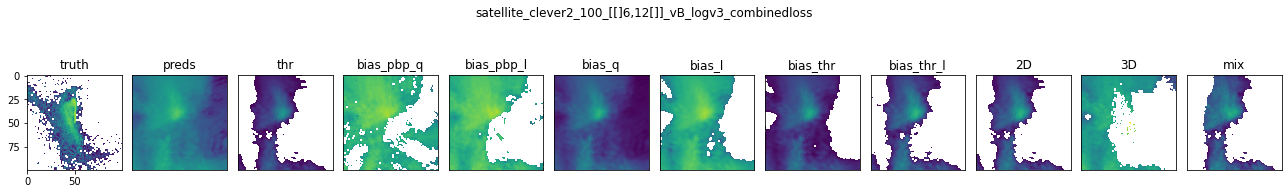

In [145]:
# plot true, predicted and bias-corrected footprints at index n for all evaluated models in list "mods"
mods =  [logv3]
n=n+5
for model in mods:
    model_to_plot = model
    fig, ax = plt.subplots(1,1+len(model_to_plot.variations), figsize=(18,3))

    ax[0].imshow(np.log10(model_to_plot.preds_test.fp.values[n]))
    ax[0].set_title("truth")
    vmax = np.max(np.log10(model_to_plot.preds_test.fp.values[n]))

    fig.suptitle(model_to_plot.model_name)

    for axn, name in enumerate(model_to_plot.variations):
        axn=axn+1
        ax[axn].imshow(np.log10(model_to_plot.variations[name][n]), vmax=vmax)
        ax[axn].set_title(name)
        ax[axn].tick_params(left = False, bottom = False, labelbottom=False, labelleft=False) 

fig.patch.set_facecolor('white')
plt.tight_layout()

preds, acc: 0.3419, iou 0.3419
thr, acc: 0.6684, iou 0.40445402298850575


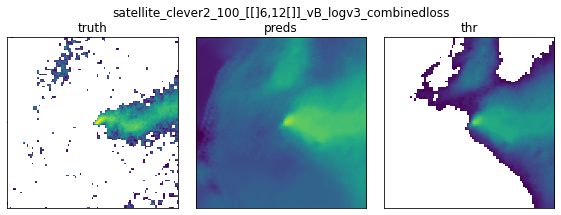

In [269]:
# plot true footprints plus only variations specified in variations_to_plot at index n for all evaluated models in list "mods"
mods =  [logv3_summer]
#n=0
n=n+5

variations_to_plot = ["preds", "thr"]

for model in mods:
    model_to_plot = model
    fig, ax = plt.subplots(1,1+len(variations_to_plot), figsize=(4*len(variations_to_plot),3))

    ax[0].imshow(np.log10(model_to_plot.preds_test.fp.values[n]))
    ax[0].set_title("truth")
    vmax = np.max(np.log10(model_to_plot.preds_test.fp.values[n]))

    fig.suptitle(model_to_plot.model_name)

    
    for axn, name in enumerate(model_to_plot.variations):
        if name in variations_to_plot:
            axn=axn+1
            ax[axn].imshow(np.log10(model_to_plot.variations[name][n]), vmax=vmax)
            ax[axn].set_title(name)

            print(f"{name}, acc: {loss.accuracy(model_to_plot.preds_test.fp.values[n][None,:,:], model_to_plot.variations[name][n][None,:,:])}, iou {loss.intersection_over_union(model_to_plot.preds_test.fp.values[n][None,:,:], model_to_plot.variations[name][n][None,:,:])}")

    for axn in ax:
        axn.tick_params(left = False, bottom = False, labelbottom=False, labelleft=False) 

fig.patch.set_facecolor('white')
plt.tight_layout()



# plotting fluxes

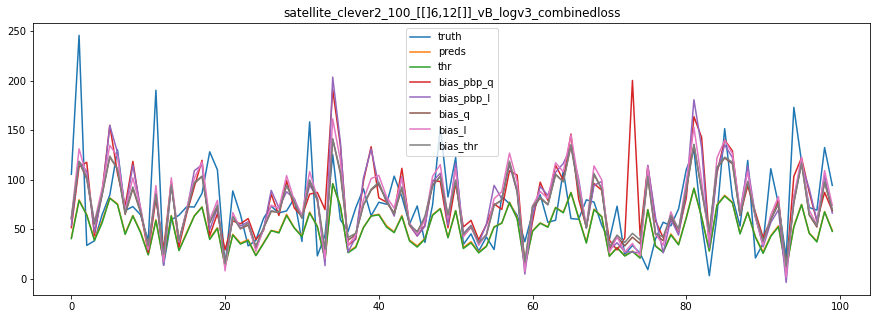

In [143]:
# plot fluxes at a particular window in time (determined by window_size and window_n). 
# Plot true flux + fluxes from all bias corrections if variations_to_plot = [], else plot only variations in list
model_to_plot = logv3

window_size = 100
window_n=0
window_n += 1 

fig = plt.figure(figsize=(15,5))

variations_to_plot = []
#variations_to_plot = ["preds", "thr", "bias_pbp_q",  "bias_pbp_l"]
variations_to_plot = ["preds", "thr", "bias_pbp_q",  "bias_pbp_l", "bias_q",  "bias_q_", "bias_l", "bias_thr"]

plt.plot(model.true_flux[window_size*window_n:window_size*(1+window_n)], label="truth")

for variation in model_to_plot.pred_fluxes:
    if len(variations_to_plot)==0 or variation in variations_to_plot: 
        plt.plot(model.pred_fluxes[variation][window_size*window_n:window_size*(1+window_n)], label=variation)

plt.title(model_to_plot.model_name)

plt.legend()

checking how bias changes with time - seasonal adjustments might be benefitial!

In [126]:
def moving_average(a, n=200):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

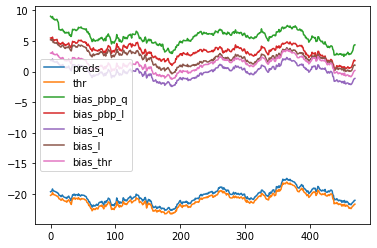

In [144]:
for variation in model_to_plot.pred_fluxes:
    if len(variations_to_plot)==0 or variation in variations_to_plot: 
        plt.plot(moving_average(model.pred_fluxes[variation] - model.true_flux), label=variation)
plt.legend()